In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow import keras
from copy import copy, deepcopy
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical

In [2]:
# Replace __FILL_ME__ with your information

# Data preparation and prepcrossing

In [3]:
# load data
(data_train, label_train), (data_test, label_test) = mnist.load_data()

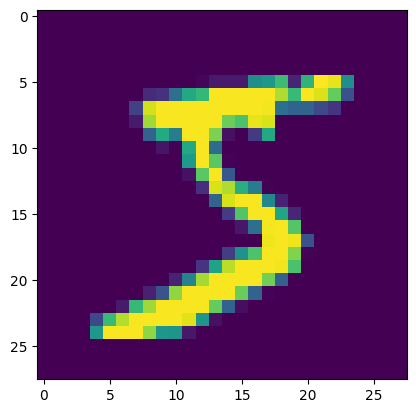

In [4]:
# display one test figure
test_fig = data_train[0]
plt.imshow(test_fig)

In [5]:
# normalize the data into the range of 0-1
data_train = data_train/data_train.max()
data_test = data_test/data_test.max()

Label = 0


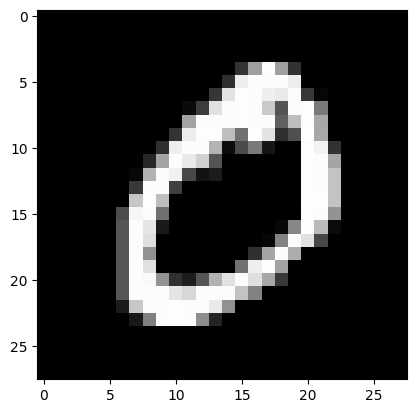

Label = 1


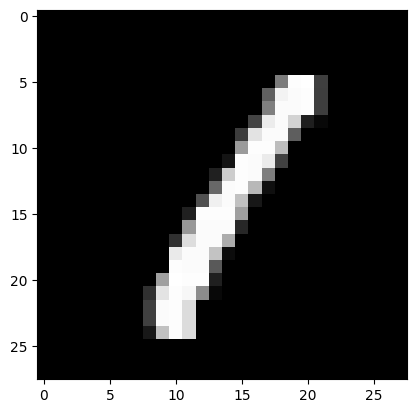

Label = 2


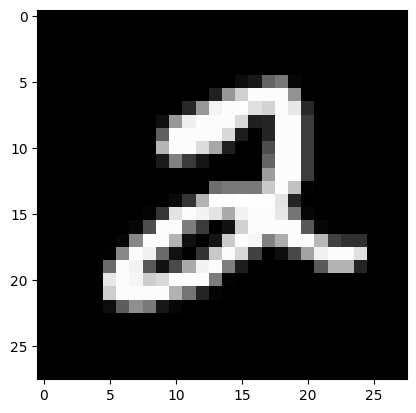

Label = 3


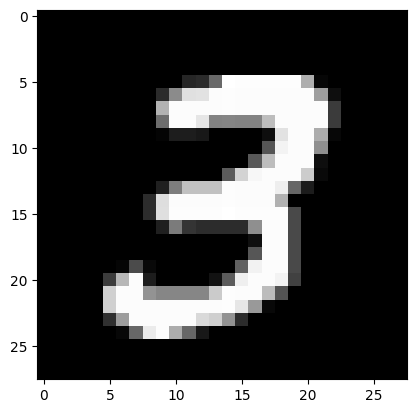

Label = 4


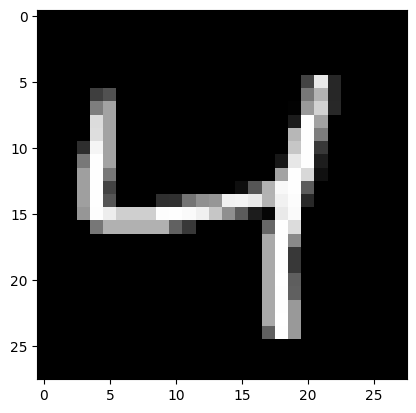

Label = 5


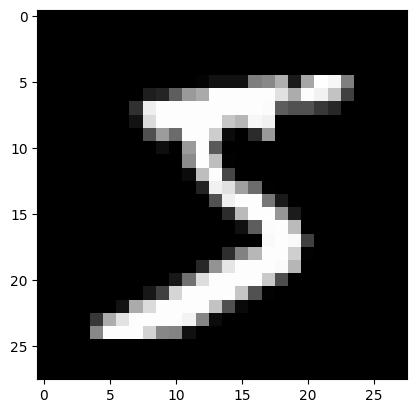

Label = 6


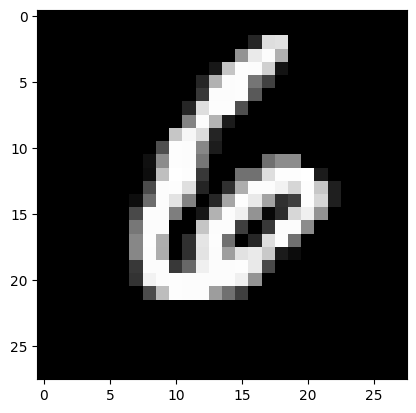

Label = 7


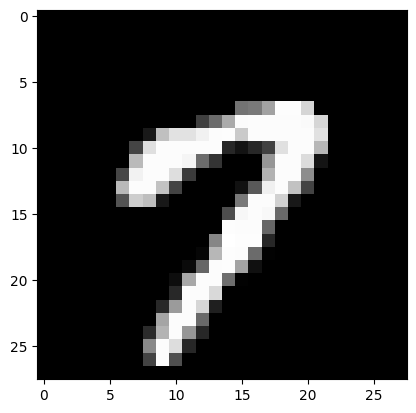

Label = 8


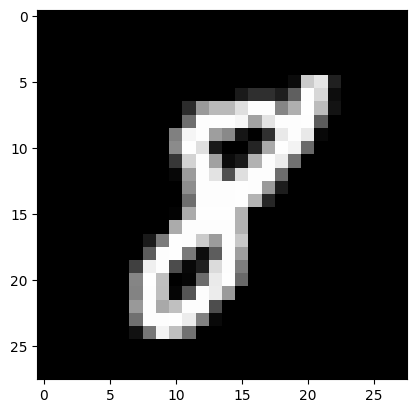

Label = 9


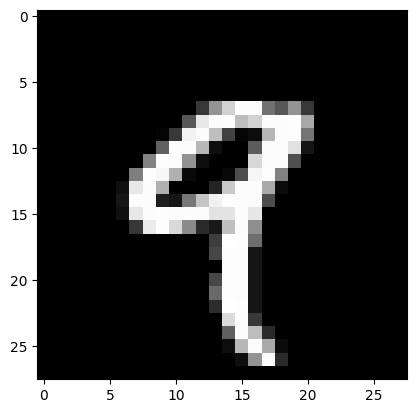

In [6]:
# display fig for each class
for i in range(10):
    for img_idx in range(10000):
        if int(label_train[img_idx]) == i:
            print('Label =', i)
            plt.imshow(data_train[img_idx], cmap = 'gray')
            plt.show()
            break
    

In [7]:
# 32 Floating Point data type is used
import sys
mem_fig = sys.getsizeof(data_train[0])
print('The required memory useage for each figure is: {}Byte'.format(mem_fig) )

The required memory useage for each figure is: 128Byte


# Construct the MLP

In [8]:
# Considerations: number of layers, number of neurons in each layer, activation function

In [9]:
# Build up the MLP
# later you can change the number of neurons and layers

input_layer = Input(shape=data_train[0].shape)
input_layer_f = Flatten()(input_layer)

hidden_layer_1     = Dense(5, name='dense_1')(input_layer_f)
hidden_layer_1_act = Activation("relu", name="act_1")(hidden_layer_1)

hidden_layer_2     = Dense(8, name='dense_2')(hidden_layer_1_act)
hidden_layer_2_act = Activation("relu", name="act_2")(hidden_layer_2)

hidden_layer_3     = Dense(8, name='dense_3')(hidden_layer_2_act)
hidden_layer_3_act = Activation("relu", name="act_3")(hidden_layer_3)

output_layer       = Dense(10, name='output_layer')(hidden_layer_3_act)
output_layer_act   = Activation("softmax", name="softmax")(output_layer)

model = Model(input_layer, output_layer_act)

In [10]:
parameter_by_layer = np.zeros([4])

# layer 1
parameter_by_layer[0] = model.get_layer('dense_1').count_params()
# layer 2
parameter_by_layer[1] = model.get_layer('dense_2').count_params()
# layer 3 
parameter_by_layer[2] = model.get_layer('dense_3').count_params()
# layer 4
parameter_by_layer[3] = model.get_layer('output_layer').count_params()

mem_model = parameter_by_layer.sum() * 32 / 1000
print('The total memory usage for weights and bias is {} kb'.format(mem_model))

The total memory usage for weights and bias is 132.32 kb


In [11]:
# check the parameter numbers
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,135 (16.15 KB)

 Trainable params: 4,135 (16.15 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [12]:
# compile model
# define optimizer to perform backpropagation, loss function to evaluate loss
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
# train model with 80% data for training and 20% for validation with specified number of epochs, a small number is reconmmand (10)
r = model.fit(data_train, label_train, validation_split= 0.2, epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6977 - loss: 0.8979 - val_accuracy: 0.8493 - val_loss: 0.5037
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8560 - loss: 0.4834 - val_accuracy: 0.8727 - val_loss: 0.4407
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8705 - loss: 0.4357 - val_accuracy: 0.8836 - val_loss: 0.4097
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8811 - loss: 0.4053 - val_accuracy: 0.8924 - val_loss: 0.3799
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8887 - loss: 0.3826 - val_accuracy: 0.8872 - val_loss: 0.3808
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8919 - loss: 0.3710 - val_accuracy: 0.8966 - val_loss: 0.3669
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8948 - loss: 0.3618 - val_accuracy: 0.8972 - val_loss: 0.3583
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8976 - loss: 0.3546 - 

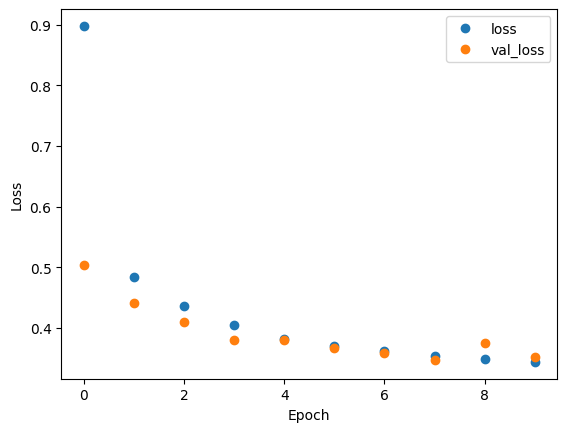

In [14]:
# plot loss
plt.plot(r.history['loss'], 'o', label='loss')
plt.plot(r.history['val_loss'], 'o', label='val_loss',)
plt.ylabel('Loss')  # Set the label for the y-axis
plt.xlabel('Epoch')  # Set the label for the x-axis
plt.legend()
plt.show()

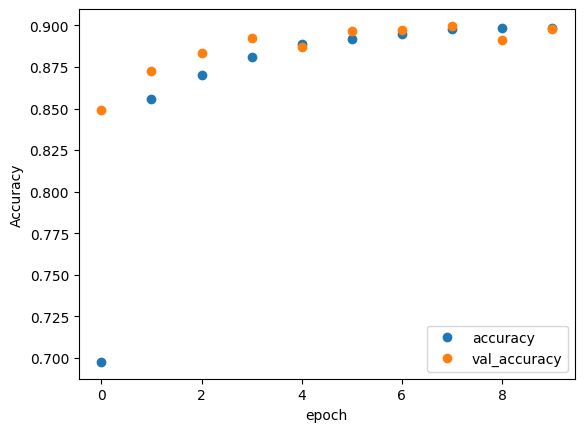

In [15]:
# Plot accuracy
plt.plot(r.history['accuracy'], 'o', label='accuracy')
plt.plot(r.history['val_accuracy'], 'o', label='val_accuracy')
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [16]:
# Evaluate the model with test dataset - evaluate() returns loss and accuracy
print("Training Accuracy: ", model.evaluate(data_train, label_train)[1])
acc_floatingpoint =  model.evaluate(data_test, label_test)[1]
print("Testing Accuracy: ", acc_floatingpoint )

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9000 - loss: 0.3410
Training Accuracy:  0.8999999761581421
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8961 - loss: 0.3682
Testing Accuracy:  0.8960999846458435


In [17]:
# save model weights
model.save_weights("weights_FP.weights.h5")

Text(0, 0.5, 'Amount')

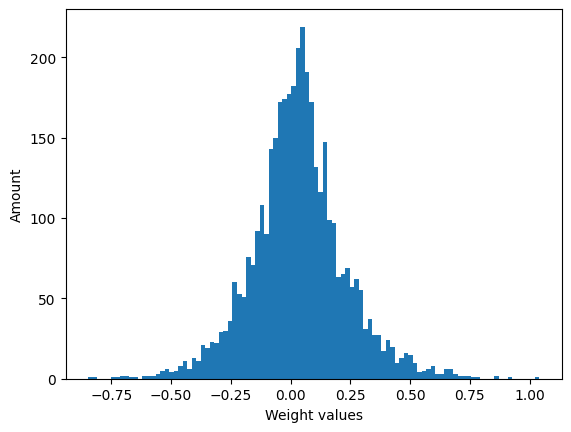

In [18]:
# observe the statistics of weights, for example in the first layer
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Amount')

In [19]:
# What can you observe from the distribution of weights?

# The weights all being close to zero pave the way for a nice fixed point quantization.

# Implement of the trained MLP with numpy

In [20]:
# implement the dense layer
def dense_layer(input_mat, input_vec, bias):
    # input_mat: (out_features, in_features)
    # input_vec: (in_features,)
    # bias: (out_features,)
    return input_mat @ input_vec + bias

In [21]:
# implement the ReLU activation function
def ReLU_layer(in_activations):
    return np.maximum(0, in_activations)

In [22]:
# implement the softmax activation function
def softmax_layer(in_activations):
    # in_activations: (n,)
    exp_z = np.exp(in_activations)
    return exp_z / np.sum(exp_z)

In [23]:
# implement your own MLP, the weighs & biases should be extracted by model.get_weights()
# the softmax layer is not necessary to be implemented
input_example_np = np.ones([28*28])

W1, b1 = model.layers[2].get_weights()
W2, b2 = model.layers[4].get_weights()
W3, b3 = model.layers[6].get_weights()
W4, b4 = model.layers[8].get_weights()

output_1 = ReLU_layer(dense_layer(input_example_np, W1, b1))
output_2 = ReLU_layer(dense_layer(output_1, W2, b2))
output_3 = ReLU_layer(dense_layer(output_2, W3, b3))
output_4 = softmax_layer(dense_layer(output_3, W4, b4))

In [24]:
# Display your own results
output_4

array([3.81397108e-09, 1.63761195e-28, 9.99999995e-01, 3.04670831e-10,
       3.47398183e-63, 2.05510988e-17, 1.59463039e-41, 9.91084443e-27,
       5.31557131e-10, 8.04295979e-25])

In [25]:
# Compare with the reference
model.predict(tf.ones((1, 28, 28)), steps=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


array([[3.8137786e-09, 1.6376659e-28, 1.0000000e+00, 3.0468081e-10,
        0.0000000e+00, 2.0551160e-17, 0.0000000e+00, 9.9112684e-27,
        5.3155058e-10, 8.0430715e-25]], dtype=float32)

# MLP fixed point quantization

In [26]:
# Quantized the weights and evaluate the best combination of Integer and Fractional parts
# Compare the inference acc. with TF model
# Estimate how much memory storage you can save with quantization 

In [27]:
# function to quantize weights with speficied bit width for integer and fractional part
def fixP_quantization(input_weight, int_BW, frac_BW):
    # int_BW must NOT include the sign bit
    resolution_ = 2**(- frac_BW)
    range_ = 2**(int_BW)
    
    weight = deepcopy(input_weight)
    
    input_weight_clipped = np.clip(weight, - range_, range_ - resolution_)
    input_weight_quantized = np.round(input_weight_clipped/resolution_) * resolution_
    
    return input_weight_quantized

In [28]:
# weight_quantization
BW_int = 1
BW_frac = 6

In [29]:
weight_quantized = [deepcopy(w) for w in model.get_weights()]

In [30]:
for i in range(len(weight_quantized)):
    weight_quantized[i] = fixP_quantization(np.copy(weight_quantized[i]), BW_int, BW_frac)

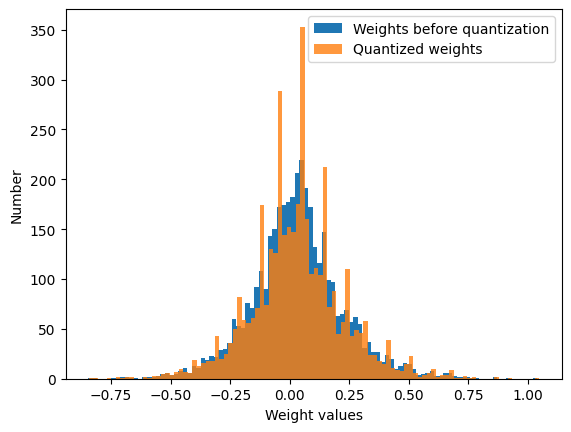

In [31]:
# plot the quantized weights in the first layer as example and compare with the floating point
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100, label = 'Weights before quantization', alpha = 1)
_ = plt.hist((weight_quantized[0].flatten()), bins = 100, label = 'Quantized weights', alpha = 0.8)
plt.xlabel('Weight values')
plt.ylabel('Number')

plt.legend()

In [32]:
# define the quantized model
model_quantized = Model(input_layer, output_layer_act)

In [33]:
# load weights and save 
model_quantized.set_weights(weight_quantized)
model_quantized.save_weights("weights_q_int_{}_frac_{}.weights.h5".format(BW_int, BW_frac))

# Evaluation of the quantization 

In [34]:
model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [35]:
# Evaluate the model - evaluate() returns loss and accuracy
print("Train Acc", model_quantized.evaluate(data_train, label_train)[1])
acc_quantized = model_quantized.evaluate(data_test, label_test)[1]
print("Test Acc:", acc_quantized)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8998 - loss: 0.3422
Train Acc 0.8997666835784912
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8948 - loss: 0.3699
Test Acc: 0.8948000073432922


In [36]:
# Summary
# 32 FP numbers utilized in baseline model
saved_memory = 1 - (1 + BW_int + BW_frac) / 32
acc_drop = acc_floatingpoint - acc_quantized

In [37]:
print("Saved memory: {}%".format(saved_memory*100))
print("Accuracy drop: {:.2f}%".format(acc_drop*100))

Saved memory: 75.0%
Accuracy drop: 0.13%


# Systematic evaluation

In [47]:
model.load_weights("weights_FP.weights.h5")

In [48]:
# parameter sweep, look for the optimal combination
BW_int = 1
acc_quantized_BW_int_1 = np.zeros(31)
saved_memory_BW_int_1  = np.zeros(31)

original_weights = [deepcopy(w) for w in model.get_weights()] # true floating-point weights, captured once

for i in range(31):
    BW_frac = i
     
    weight_quantized = [np.copy(w) for w in original_weights]
    for j in range(len(weight_quantized)): # quantize weights layer by layer
        weight_quantized[j] = fixP_quantization(weight_quantized[j], BW_int, BW_frac)
    
        
    
    model_quantized = Model(input_layer, output_layer_act) # define the quantized model
    model_quantized.set_weights(weight_quantized) # load quantized weights
    # model_quantized.save_weights("weights_q_int{}_frac_{}.h5".format(BW_int, BW_frac)) # save quantized weights
    
    model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) # compile model
    
    print("BW_int = {} BW_frac = {} " .format(BW_int, BW_frac))
    acc_quantized_BW_int_1[i] = model_quantized.evaluate(data_test, label_test)[1] # acc evaluation
    saved_memory_BW_int_1[i] = 1 - (BW_int + BW_frac) / 32  # save memory evaluation
    print("The saved memory is {}" .format(saved_memory_BW_int_1[i]))

BW_int = 1 BW_frac = 0 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1033 - loss: 4.4643
The saved memory is 0.96875
BW_int = 1 BW_frac = 1 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2521 - loss: 6.2895
The saved memory is 0.9375
BW_int = 1 BW_frac = 2 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7775 - loss: 0.7441
The saved memory is 0.90625
BW_int = 1 BW_frac = 3 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8574 - loss: 0.4738
The saved memory is 0.875
BW_int = 1 BW_frac = 4 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8907 - loss: 0.3876
The saved memory is 0.84375
BW_int = 1 BW_frac = 5 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8951 - loss: 0.3728
The saved memory is 0.8125
BW_int = 1 BW_frac = 6 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8948 - loss: 0.3699
The saved memory is 0.78125
BW_int = 1 BW_frac = 7 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8974 - loss: 0.3651
The saved memory

Text(0.5, 1.0, 'BW_int = 1')

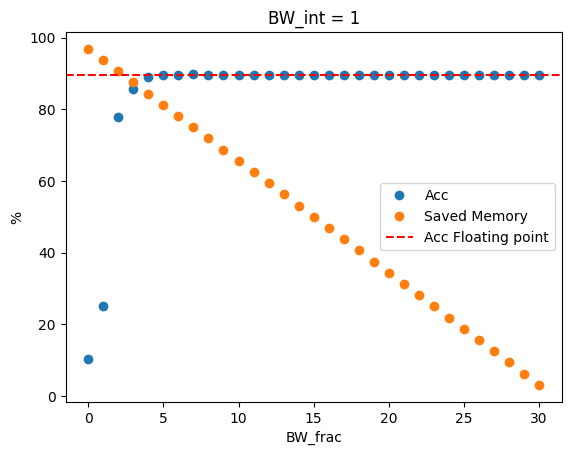

In [49]:
# result visualization
plt.plot(acc_quantized_BW_int_1*100, 'o', label = 'Acc')
plt.plot(saved_memory_BW_int_1*100, 'o', label = 'Saved Memory')
plt.xlabel('BW_frac')
plt.ylabel('%')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.legend()
plt.title("BW_int = 1")

In [51]:
# parameter sweep
BW_int = 2
acc_quantized_BW_int_2 = np.zeros(30)
saved_memory_BW_int_2  = np.zeros(30)

original_weights = [deepcopy(w) for w in model.get_weights()] # true floating-point weights, captured once

for i in range(30):
    BW_frac = i
     
    weight_quantized = [np.copy(w) for w in original_weights]
    for j in range(len(weight_quantized)): # quantize weights layer by layer
        weight_quantized[j] = fixP_quantization(weight_quantized[j], BW_int, BW_frac)
    
        
    model_quantized = Model(input_layer, output_layer_act) # define the quantized model
    model_quantized.set_weights(weight_quantized) # load quantized weights
    model_quantized.save_weights("weights_q_int{}_frac{}.weights.h5".format(BW_int, BW_frac)) # save quantized weights
    
    model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) # compile model
    
    print("BW_int = {} BW_frac = {} " .format(BW_int, BW_frac))
    acc_quantized_BW_int_2[i] = model_quantized.evaluate(data_test, label_test)[1] # acc evaluation
    saved_memory_BW_int_2[i] = 1 - (BW_int + BW_frac) / 32  # save memory evaluation
    print("The saved memory is {}" .format(saved_memory_BW_int_2[i]))

BW_int = 2 BW_frac = 0 
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1033 - loss: 4.4643
The saved memory is 0.9375
BW_int = 2 BW_frac = 1 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1033 - loss: 4.4643
The saved memory is 0.90625
BW_int = 2 BW_frac = 2 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1033 - loss: 4.4643
The saved memory is 0.875
BW_int = 2 BW_frac = 3 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1033 - loss: 4.4643
The saved memory is 0.84375
BW_int = 2 BW_frac = 4 
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1033 - loss: 4.4643
The saved memory is 0.8125
BW_int = 2 BW_frac = 5 
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1033 - loss: 4.4643
The saved memory is 0.78125
BW_int = 2 BW_frac = 6 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1033 - loss: 4.4643
The saved memory is 0.75
BW_int = 2 BW_frac = 7 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1033 - loss: 4.4643
The saved memory is

Text(0.5, 1.0, 'BW_int = 2')

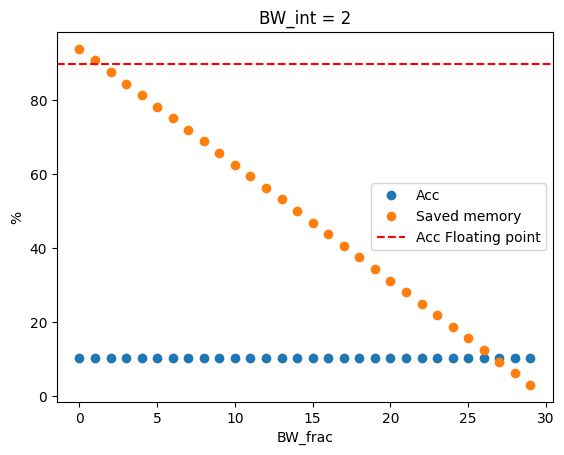

In [53]:
plt.plot(acc_quantized_BW_int_2*100, 'o', label = 'Acc')
plt.plot(saved_memory_BW_int_2*100, 'o', label = 'Saved memory')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.xlabel('BW_frac')
plt.ylabel('%')
plt.legend()
plt.title("BW_int = 2")